In [1]:
import os

import IPython.display as ipd
import keras
import librosa
import matplotlib.pyplot as plt 
import numpy as np
import random
import seaborn as sns
import tensorflow as tf

from keras.models import Sequential
from keras.layers import BatchNormalization, Conv2D, Dense, Dropout, Flatten, MaxPool2D, Reshape

In [2]:
train_real_directory = "/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/real"
train_fake_directory = "/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/fake"

validation_real_directory = "/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/real"
validation_fake_directory = "/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/fake"

test_real_directory = "/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/testing/real"
test_fake_directory = "/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/testing/fake"

In [4]:
# Get waveform (.wav) audio files

train_real_audio = [os.path.join(train_real_directory, file) for file in os.listdir(train_real_directory) if file.endswith('.wav')]
train_fake_audio = [os.path.join(train_fake_directory, file) for file in os.listdir(train_fake_directory) if file.endswith('.wav')]

validation_real_audio = [os.path.join(validation_real_directory, file) for file in os.listdir(validation_real_directory) if file.endswith('.wav')]
validation_fake_audio = [os.path.join(validation_fake_directory, file) for file in os.listdir(validation_fake_directory) if file.endswith('.wav')]

test_real_audio = [os.path.join(test_real_directory, file) for file in os.listdir(test_real_directory) if file.endswith('.wav')]
test_fake_audio = [os.path.join(test_fake_directory, file) for file in os.listdir(test_fake_directory) if file.endswith('.wav')]

Train Set:
Train Real - Number of files: 26941
Train Real - Duration (seconds): min=0.00, max=38.68, mean=4.68
Train Real - Example file: /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/real/file30736.wav_16k.wav_norm.wav_mono.wav_silence.wav
Train Fake - Number of files: 26927
Train Fake - Duration (seconds): min=0.12, max=12.47, mean=1.68
Train Fake - Example file: /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/training/fake/file14215.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav

Validation Set:
Validation Real - Number of files: 5400
Validation Real - Duration (seconds): min=0.11, max=17.02, mean=4.64
Validation Real - Example file: /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/validation/real/file30967.wav_16k.wav_norm.wav_mono.wav_silence.wav
Validation Fake - Number of files: 5398
Validation Fake - Duration (seconds): min=0.23, max=8.41, mean=1.69
Validation Fake - Example file: /kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/valid

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


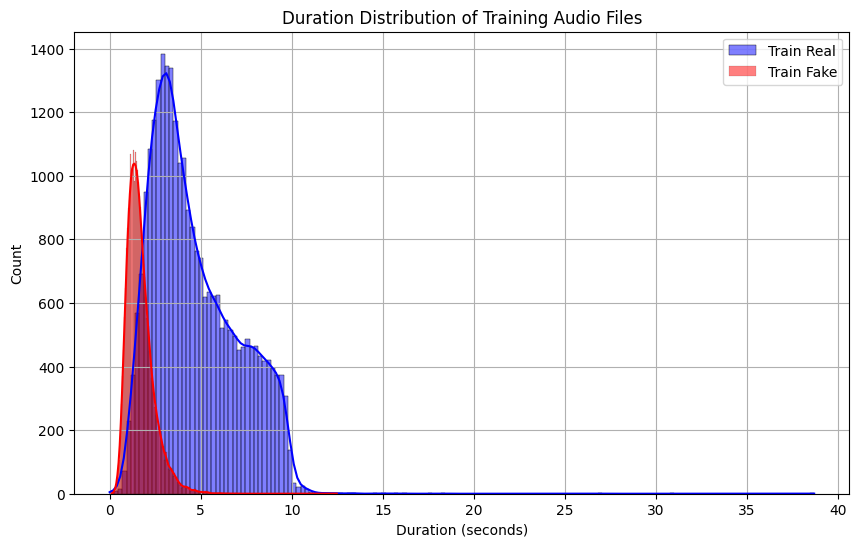

In [5]:
# Function to get duration of audio file
def get_audio_duration(file_path):
    y, sr = librosa.load(file_path, sr=None)
    return librosa.get_duration(y=y, sr=sr)

# Function to analyze a list of audio files
def analyze_audio_files(audio_files, label):
    durations = [get_audio_duration(file) for file in audio_files]
    print(f"{label} - Number of files: {len(audio_files)}")
    print(f"{label} - Duration (seconds): min={np.min(durations):.2f}, max={np.max(durations):.2f}, mean={np.mean(durations):.2f}")
    print(f"{label} - Example file: {audio_files[0]}")
    return durations

print("Train Set:")
train_real_durations = analyze_audio_files(train_real_audio, "Train Real")
train_fake_durations = analyze_audio_files(train_fake_audio, "Train Fake")

print("\nValidation Set:")
validation_real_durations = analyze_audio_files(validation_real_audio, "Validation Real")
validation_fake_durations = analyze_audio_files(validation_fake_audio, "Validation Fake")

print("\nTest Set:")
test_real_durations = analyze_audio_files(test_real_audio, "Test Real")
test_fake_durations = analyze_audio_files(test_fake_audio, "Test Fake")

# Optional: Plot distribution of durations
plt.figure(figsize=(10, 6))
sns.histplot(train_real_durations, color='blue', label='Train Real', kde=True)
sns.histplot(train_fake_durations, color='red', label='Train Fake', kde=True)
plt.title("Duration Distribution of Training Audio Files")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Taking a random audio file
random_audio_file = train_real_audio[random.randint(0, 6977)]
ipd.Audio(random_audio_file)

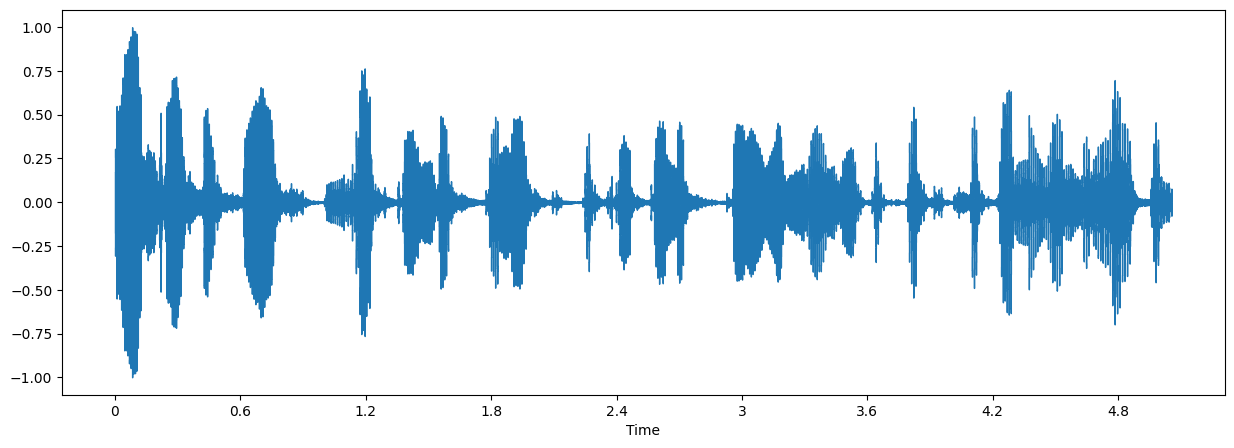

In [7]:
# Visualize waveform of sample audio above
# sr (sample rate) refers to the frequency of "snapshots" of the audio used for digital representation
audio_data, sample_rate = librosa.load(random_audio_file)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(audio_data, sr=sample_rate)

In [8]:
# Convert audio file to spectrogram
# def create_spectrogram(file_path):
#     audio_data, sample_rate = librosa.load(file_path)
#     spectrogram = librosa.stft(audio_data)
#     decibel_spectrogram = librosa.amplitude_to_db(abs(spectrogram))
#     return decibel_spectrogram

# Convert audio file to mel-scale spectrogram
# See https://medium.com/analytics-vidhya/understanding-the-mel-spectrogram-fca2afa2ce53
def create_mel_spectrogram(file_path):
    audio_data, sample_rate = librosa.load(file_path)  
    # Convert audio to mel-based spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sample_rate)
    # Convert from amplitude squared to decibel units
    mel_decibel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)  
    return mel_decibel_spectrogram

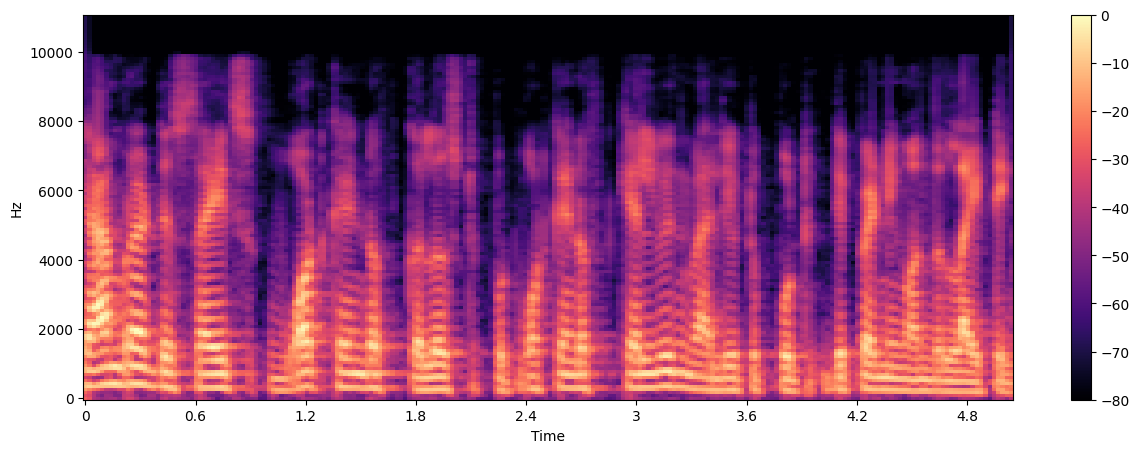

In [9]:
# Spectrogram representation of the sample wave form above
sample_spectrogram = create_mel_spectrogram(random_audio_file)
plt.figure(figsize=(15, 5))
librosa.display.specshow(sample_spectrogram, x_axis='time', y_axis='hz')
plt.colorbar()

In [10]:
from tqdm import tqdm

# Resize spectrogram to a fixed shape (128, 87) to make sure they are homogeneous
def resize_spectrogram(spectrogram, target_shape=(128, 87)):
    # Resize the spectrogram to the target shape
    return np.resize(spectrogram, target_shape)

# Use spectrograms as features to train the model
def get_features_and_labels(real_audio_files, fake_audio_files):
    spec_arr = []
    labels = []
    
    # Loop over real audio files with a progress bar
    for file in tqdm(real_audio_files, desc="Processing real audio files", unit="file"):
        spectrogram = create_mel_spectrogram(file)
        spectrogram_resized = resize_spectrogram(spectrogram)
        spec_arr.append(spectrogram_resized)
        labels.append(0)
    
    # Loop over fake audio files with a progress bar
    for file in tqdm(fake_audio_files, desc="Processing fake audio files", unit="file"):
        spectrogram = create_mel_spectrogram(file)
        spectrogram_resized = resize_spectrogram(spectrogram)
        spec_arr.append(spectrogram_resized)
        labels.append(1)
    
    return np.array(spec_arr), np.array(labels)

# Now use the function as before
train_features, train_labels = get_features_and_labels(train_real_audio, train_fake_audio)
validation_features, validation_labels = get_features_and_labels(validation_real_audio, validation_fake_audio)
test_features, test_labels = get_features_and_labels(test_real_audio, test_fake_audio)

Processing real audio files:   1%|▏         | 363/26941 [00:11<13:38, 32.48file/s]


KeyboardInterrupt: 

In [12]:
import numpy as np

# Save features and labels in compressed .npz format
def save_features_and_labels_compressed(features, labels, filename):
    np.savez_compressed(filename, features=features, labels=labels)
    print(f"Features and labels saved to {filename}")

# File paths where the features and labels will be saved in compressed format
train_file = "/kaggle/input/deepfake-extracted-features/Train Features Labels.npz"
validation_file = "/kaggle/input/deepfake-extracted-features/Validation Features Labels.npz"
test_file = "/kaggle/input/deepfake-extracted-features/Test Features Labels.npz"

# Save the features and labels for train, validation, and test sets in compressed .npz files
save_features_and_labels_compressed(train_features, train_labels, train_file)
save_features_and_labels_compressed(validation_features, validation_labels, validation_file)
save_features_and_labels_compressed(test_features, test_labels, test_file)

NameError: name 'train_features' is not defined

In [13]:
import os

import IPython.display as ipd
import keras
import librosa
import matplotlib.pyplot as plt 
import numpy as np
import random
import seaborn as sns
import tensorflow as tf

from keras.models import Sequential
from keras.layers import BatchNormalization, Conv2D, Dense, Dropout, Flatten, MaxPool2D, Reshape

In [14]:
# Load the saved compressed features and labels
def load_features_and_labels_compressed(filename):
    data = np.load(filename)
    features = data['features']
    labels = data['labels']
    print(f"Loaded features and labels from {filename}")
    return features, labels

train_file = "/kaggle/input/deepfake-extracted-features/Train Features Labels.npz"
validation_file = "/kaggle/input/deepfake-extracted-features/Validation Features Labels.npz"
test_file = "/kaggle/input/deepfake-extracted-features/Test Features Labels.npz"

# Example of loading saved compressed features and labels
train_features, train_labels = load_features_and_labels_compressed(train_file)
validation_features, validation_labels = load_features_and_labels_compressed(validation_file)
test_features, test_labels = load_features_and_labels_compressed(test_file)

Loaded features and labels from /kaggle/input/deepfake-extracted-features/Train Features Labels.npz
Loaded features and labels from /kaggle/input/deepfake-extracted-features/Validation Features Labels.npz
Loaded features and labels from /kaggle/input/deepfake-extracted-features/Test Features Labels.npz


In [ ]:
# we've essentially converted audio into images for machine learning

In [15]:
print("train features shape: {}".format(train_features.shape))
print("test features shape: {}".format(test_features.shape))

train features shape: (53868, 128, 87)
test features shape: (4634, 128, 87)


In [16]:
# Significantly trimmed VGG model to optimize results

trimmed_vgg = Sequential()
trimmed_vgg.add(Reshape((128, 87, 1),input_shape=train_features.shape[1:]))

trimmed_vgg.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation='relu'))
trimmed_vgg.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation='relu'))
trimmed_vgg.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

trimmed_vgg.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation='relu'))
trimmed_vgg.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation='relu'))
trimmed_vgg.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

trimmed_vgg.add(Flatten())
trimmed_vgg.add(Dense(units=256,activation="relu"))
trimmed_vgg.add(Dense(units=256,activation="relu"))
trimmed_vgg.add(Dense(1, activation="sigmoid"))

trimmed_vgg.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 128, 87, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 87, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 87, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 43, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86016)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,020,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,345,409 (85.24 MB)

 Trainable params: 22,345,409 (85.24 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Compile model
# Adam optimiser helps model get unstuck when stuck at local minima
trimmed_vgg.compile(optimizer=keras.optimizers.Adam(),
                    loss=keras.losses.binary_crossentropy, 
                    metrics=["accuracy"])

In [18]:
trimmed_vgg_history = trimmed_vgg.fit(train_features,
                                      train_labels,
                                      validation_data = [validation_features, validation_labels],
                                      batch_size = 32,
                                      epochs = 10,
                                      steps_per_epoch = 300)

Epoch 1/10


I0000 00:00:1745245734.804916     119 service.cc:145] XLA service 0x7a9770007740 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745245734.804978     119 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745245734.804985     119 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


  4/300 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.4844 - loss: 67.7327 

I0000 00:00:1745245745.436324     119 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


300/300 ━━━━━━━━━━━━━━━━━━━━ 35s 74ms/step - accuracy: 0.6242 - loss: 5.3293 - val_accuracy: 0.7728 - val_loss: 0.4959
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 63ms/step - accuracy: 0.7631 - loss: 0.4702 - val_accuracy: 0.8339 - val_loss: 0.3741
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - accuracy: 0.8400 - loss: 0.3655 - val_accuracy: 0.8027 - val_loss: 0.3921
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - accuracy: 0.8477 - loss: 0.3430 - val_accuracy: 0.8562 - val_loss: 0.3261
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.8729 - loss: 0.2999 - val_accuracy: 0.8923 - val_loss: 0.2657
Epoch 6/10
184/300 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.8814 - loss: 0.2787

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.8813 - loss: 0.2805 - val_accuracy: 0.8947 - val_loss: 0.2646
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.8921 - loss: 0.2780 - val_accuracy: 0.9105 - val_loss: 0.2244
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.9090 - loss: 0.2281 - val_accuracy: 0.9105 - val_loss: 0.2299
Epoch 9/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.9074 - loss: 0.2406 - val_accuracy: 0.9079 - val_loss: 0.2326
Epoch 10/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.9152 - loss: 0.2244 - val_accuracy: 0.9018 - val_loss: 0.2278


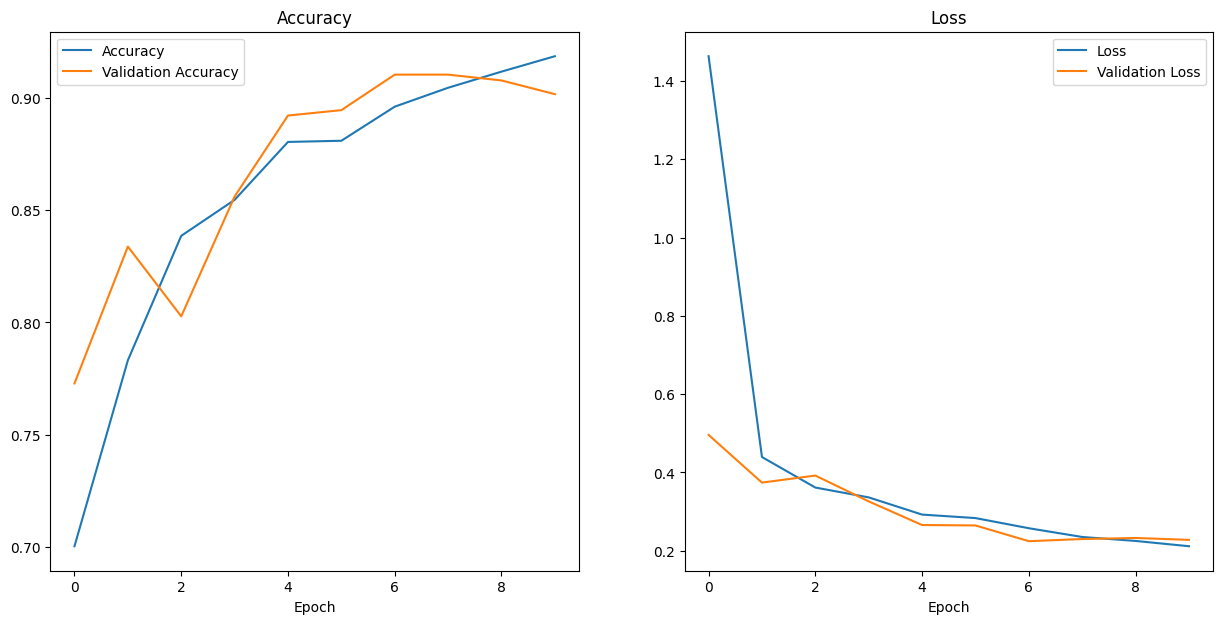

In [19]:
# Note that extremely high accuracy is not due to model overfitting,
# it's because the dataset is very "easy" relative to actual modern state of deepfaked audio
# i.e. the fakes are mostly easily detectable, even to the human ear

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.plot(trimmed_vgg_history.history["accuracy"])
ax1.plot(trimmed_vgg_history.history['val_accuracy'])
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend(["Accuracy","Validation Accuracy"])

ax2.plot(trimmed_vgg_history.history["loss"])
ax2.plot(trimmed_vgg_history.history["val_loss"])
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend(["Loss","Validation Loss"])

plt.show()

In [20]:
# Test Data Results

trimmed_vgg_loss, trimmed_vgg_accuracy = trimmed_vgg.evaluate(test_features, test_labels)

145/145 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.7519 - loss: 0.5356


In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
test_predictions = (trimmed_vgg.predict(test_features) > 0.5).astype("int32")

# Compute Precision, Recall, F1 Score
precision = precision_score(test_labels, test_predictions)
recall = recall_score(test_labels, test_predictions)
f1 = f1_score(test_labels, test_predictions)

# Print the metrics
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step
Precision: 0.7691
Recall: 0.8266
F1 Score: 0.7968


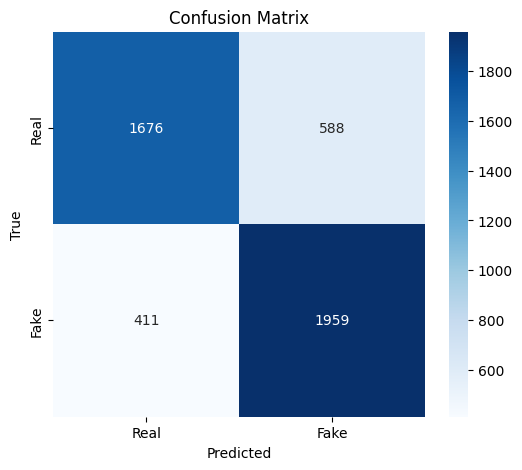

In [22]:
# Compute Confusion Matrix
cm = confusion_matrix(test_labels, test_predictions)

# Plot Confusion Matrix using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


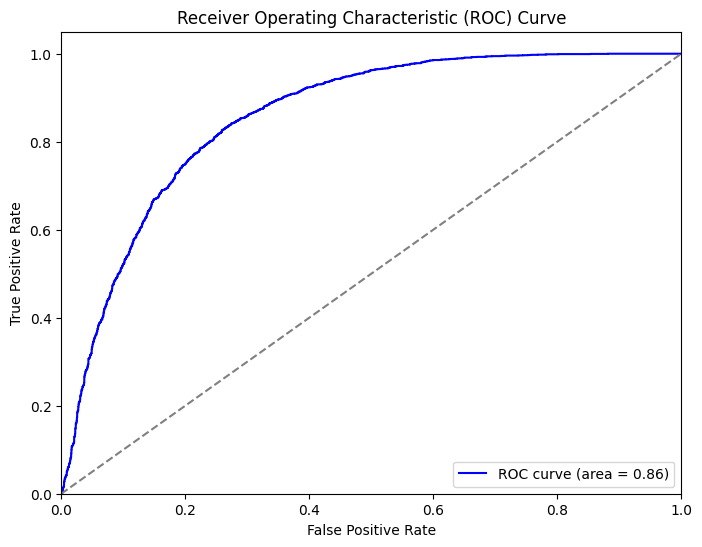

In [23]:
fpr, tpr, thresholds = roc_curve(test_labels, trimmed_vgg.predict(test_features))
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [24]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(test_labels, test_predictions, target_names=["Real", "Fake"])

# Print the report
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

        Real       0.80      0.74      0.77      2264
        Fake       0.77      0.83      0.80      2370

    accuracy                           0.78      4634
   macro avg       0.79      0.78      0.78      4634
weighted avg       0.79      0.78      0.78      4634



In [25]:
# Saving the final version

trimmed_vgg.save('deepfake_audio_detector_final_2.h5')

In [26]:
from IPython.display import FileLink

# This will create a clickable link to download the model
FileLink('deepfake_audio_detector_final_2.h5')

/kaggle/working/deepfake_audio_detector_final_2.h5